# Lab 5 : Mixture Models+Model orden selection 

Welcome to the advanced Machine Learning Course.

The objective of this lab session is to code a few regression algorithms and to apply them to synthetic and real datasets.

Please put **"ML - MDS - TD5"** in the mail subject or I might lose your work (which means 0) and send it to pierre.houdouin@centralesupelec.fr

Please label your notebook **"L5_familyname1_familyname2.ipynb"** or I might lose your work (which means 0).

We begin with the standard imports:

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.datasets import make_moons, make_blobs, make_circles

%matplotlib inline
sns.set_context('poster')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.25, 's' : 80, 'linewidths':0}

## GMM

A Gaussian mixture model is a probabilistic model that assumes all the data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters. After estimation of those parameters we get an estimation of the distribution of our data. For the clustering task, one can think of mixture models as generalizing k-means clustering to incorporate information about the covariance structure of the data as well as the centers of the latent Gaussians. 

### First part

Fill in the following class to implement a multivariate GMM:

$\mu = \frac{1}{n} \sum_{i=1}^n x_i$

In [3]:
class my_GMM():
    
    def __init__(self, k):
        '''
        Parameters:
        k: integer
            number of components
        
        Attributes:
        
        alpha_: np.array
            proportion of components
        mu_: np.array
            array containing means
        Sigma_: np.array
            array cointaining covariance matrix
        cond_prob_: (n, K) np.array
            conditional probabilities for all data points 
        labels_: (n, ) np.array
            labels for data points
        '''
        self.k = k
        self.alpha_ = None
        self.mu_ = None
        self.Sigma_ = None
        self.cond_prob_ = None
        self.labels_ = None
        
    def fit(self, X):
        """ Find the parameters
        that better fit the data
        
        Parameters:
        -----------
        X: (n, p) np.array
            Data matrix
        
        Returns:
        -----
        self
        """
        
        def compute_condition_prob_matrix(X, alpha, mu, Sigma):
            '''Compute the conditional probability matrix 
            shape: (n, K)
            '''
            n, p = X.shape
            cond_prob = np.zeros((n, self.k))
            for i in range(self.k):
                cond_prob[:, i] = alpha[i] * multivariate_normal.pdf(X, mean=mu[i], cov=Sigma[i])
        
            return cond_prob
        
        n, p = X.shape

        # Initialization using KMeans
        kmeans = KMeans(n_clusters=self.k, n_init=5, random_state=0).fit(X)
        labels = kmeans.labels_
        self.mu_ = kmeans.cluster_centers_

        self.Sigma_ = [np.cov(X[labels == i].T) + 1e-10 * np.eye(p) for i in range(self.k)]
        self.alpha_ = [np.mean(labels == i) for i in range(self.k)]
        
        # EM algorithm
        diff = np.inf
        prev_likelihood = 0

        while diff > 1e-6:
            # E-step
            self.cond_prob_ = compute_condition_prob_matrix(X, self.alpha_, self.mu_, self.Sigma_)
            self.cond_prob_ /= self.cond_prob_.sum(axis=1, keepdims=True)

            # M-step
            N_k = self.cond_prob_.sum(axis=0)
            self.alpha_ = N_k / n
            self.mu_ = np.dot(self.cond_prob_.T, X) / N_k[:, np.newaxis]

            self.Sigma_ = []
            for i in range(self.k):
                diff_i = X - self.mu_[i]
                cov_i = np.dot((self.cond_prob_[:, i][:, np.newaxis] * diff_i).T, diff_i) / N_k[i]
                self.Sigma_.append(cov_i + 1e-10 * np.eye(p))

            likelihood = np.sum(np.log(compute_condition_prob_matrix(X, self.alpha_, self.mu_, self.Sigma_).sum(axis=1)))
            diff = np.abs(likelihood - prev_likelihood)
            prev_likelihood = likelihood

        self.labels_ = np.argmax(self.cond_prob_, axis=1)
        return self
    

    def predict(self, X):
        """ Predict labels for X
        
        Parameters:
        -----------
        X: (n, p) np.array
            New data matrix
        
        Returns:
        -----
        label assigment        
        """
        cond_prob = self.compute_proba(X)
        return np.argmax(cond_prob, axis=1)
        
    def compute_proba(self, X):
        """ Compute probability vector for X
        
        Parameters:
        -----------
        X: (n, p) np.array
            New data matrix
        
        Returns:
        -----
        proba: (n, k) np.array        
        """
        n = X.shape[0]
        cond_prob = np.zeros((n, self.k))
        for i in range(self.k):
            cond_prob[:, i] = self.alpha_[i] * multivariate_normal.pdf(X, mean=self.mu_[i], cov=self.Sigma_[i])
        cond_prob /= cond_prob.sum(axis=1, keepdims=True)
        return cond_prob

Generate your own mixture of Gaussian distributions to test the model, choose parameters so that GMM performs better than K-Means on it. Use `np.random.multivariate_normal`. 

Plot data with colors representing predicted labels and shapes representing real labels.

In [4]:
# We introduce this clustering accuracy function in order to compute the accuracy of the clustering methods
def clustering_accuracy(y_true, y_pred):
    """Compute best label-matching clustering accuracy."""
    cm = confusion_matrix(y_true, y_pred)
    # Hungarian algorithm (maximize total matches)
    row_ind, col_ind = linear_sum_assignment(-cm)
    return cm[row_ind, col_ind].sum() / np.sum(cm)

In [ ]:
# And we introduce this function to compare the clustering results of GMM and K-Means for a given X and its true labels y_true
def compare_clustering(X, y_true, dataset):
    # In order to better compare the two methods and truly determine which one performs best
    # we will fix the number of clusters to the true number of clusters
    # taking it out of the equation of comparison
    n_clusters = len(np.unique(y_true))

    # GMM
    gmm = my_GMM(k=n_clusters)
    gmm.fit(X)
    y_gmm = gmm.labels_

    # KMeans
    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    y_kmeans = kmeans.fit_predict(X)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Comparison on dataset: {dataset}", fontsize=16)

    markers = ['o', 's', '^', 'D', 'v', 'P', '*']
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

    for i in range(n_clusters):
        for j in range(n_clusters):
            mask = (y_gmm == i) & (y_true == j)
            axes[0].scatter(X[mask, 0], X[mask, 1], marker=markers[j], color=colors[i], edgecolor='k', s=50, alpha=0.7)
    
    axes[0].set_title("GMM clustering\n(color=pred, shape=true)")
    axes[0].grid(True)

    for i in range(n_clusters):
        for j in range(n_clusters):
            mask = (y_kmeans == i) & (y_true == j)
            axes[1].scatter(X[mask, 0], X[mask, 1], marker=markers[j], color=colors[i], edgecolor='k', s=50, alpha=0.7)
    
    axes[1].set_title("K-Means clustering\n(color=pred, shape=true)")
    axes[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Accuracy
    acc_gmm = clustering_accuracy(y_true, y_gmm)
    acc_kmeans = clustering_accuracy(y_true, y_kmeans)

    print(f"Results on dataset: {dataset}")
    print(f"GMM accuracy: {acc_gmm:.2f}")
    print(f"K-Means accuracy: {acc_kmeans:.2f}")

C:\Users\adoni\AppData\Local\Temp\ipykernel_6312\2393967898.py:14: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X1 = np.random.multivariate_normal(mu1, Sigma1, 200)


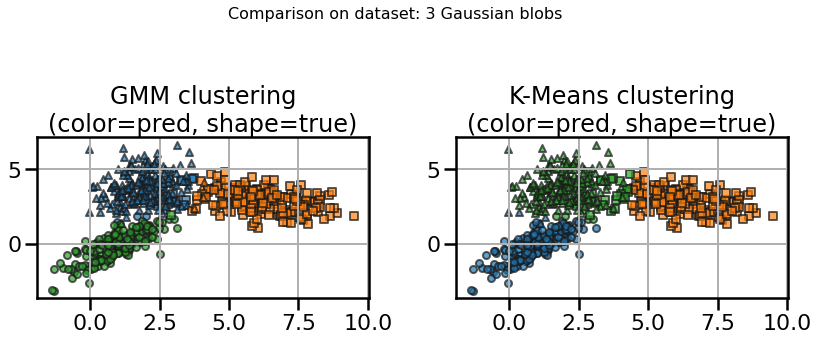

Results on dataset: 3 Gaussian blobs
GMM accuracy: 0.96
K-Means accuracy: 0.94


In [6]:
# Parameters
mu1 = [1, 0]
Sigma1 = [[1.0, 0.9],
          [0.8, 1.0]]

mu2 = [6, 3]
Sigma2 = [[1.8, -0.3],
          [-0.3, 0.5]]

mu3 = [2, 4]
Sigma3 = [[0.7, 0.0],
          [0.0, 1.3]]

X1 = np.random.multivariate_normal(mu1, Sigma1, 200)
X2 = np.random.multivariate_normal(mu2, Sigma2, 200)
X3 = np.random.multivariate_normal(mu3, Sigma3, 200)

X = np.vstack((X1, X2, X3))
y_true = np.array([0]*200 + [1]*200 + [2]*200);

compare_clustering(X, y_true, dataset="3 Gaussian blobs")

We will also compare the clustering accuracy of GMM and K-Means for some generated datasets, such as blobs, moons and circles.

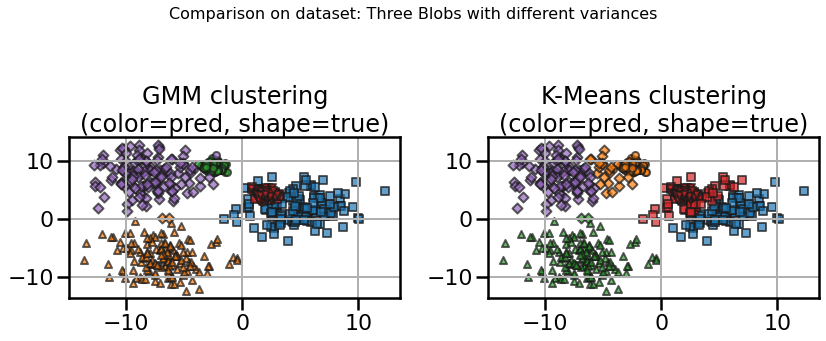

Results on dataset: Three Blobs with different variances
GMM accuracy: 0.98
K-Means accuracy: 0.90


In [65]:
X, y_true = make_blobs(n_samples=700, centers=5, n_features=2, random_state=42, cluster_std=[0.5, 2.5, 2.5, 2.5, 0.5])

compare_clustering(X, y_true, dataset="Three Blobs with different variances")

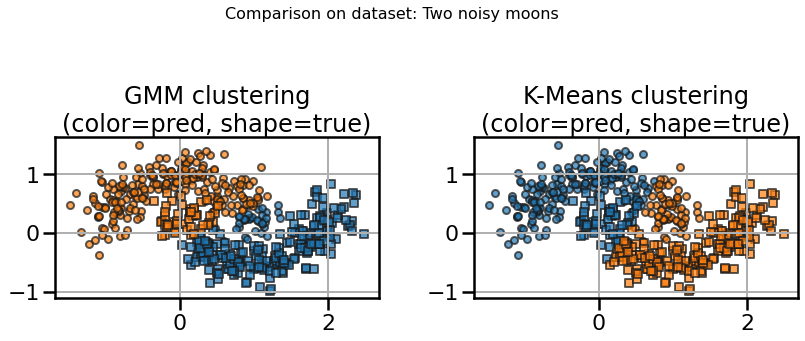

Results on dataset: Two noisy moons
GMM accuracy: 0.84
K-Means accuracy: 0.76


In [17]:
X, y_true = make_moons(n_samples=500, noise=0.2, random_state=42)

compare_clustering(X, y_true, dataset="Two noisy moons")

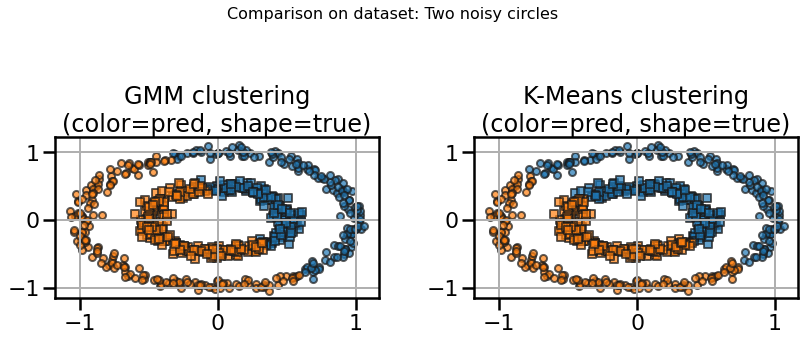

Results on dataset: Two noisy circles
GMM accuracy: 0.52
K-Means accuracy: 0.50


In [35]:
X, y_true = make_circles(n_samples=600, noise=0.05, factor=0.5, random_state=42)

compare_clustering(X, y_true, dataset="Two noisy circles")

We can clearly see that GMM outperforms K-Means on all of these datasets.

We also test on a uniform distribution dataset where both algorithms try to find meaningful clusters in pure noise. Here, both algorithms perform poorly as expected.

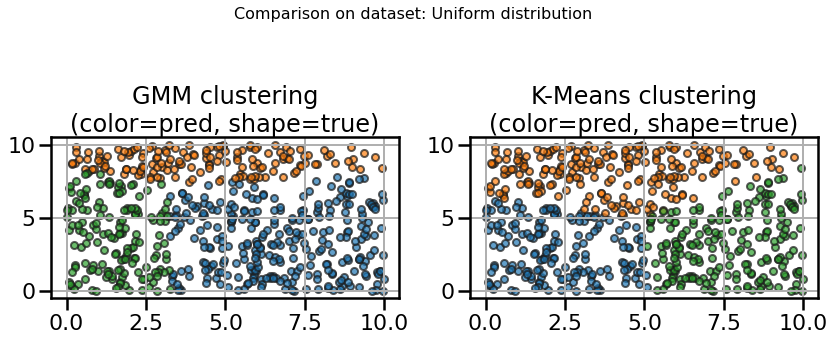

In [ ]:
X = np.random.uniform(low=0, high=10, size=(600, 2))
y_true = np.zeros(600, dtype=int)
dataset = "Uniform distribution"
n_clusters = 3

# GMM
gmm = my_GMM(k=n_clusters)
gmm.fit(X)
y_gmm = gmm.labels_

# KMeans
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Comparison on dataset: {dataset}", fontsize=16)
markers = ['o', 's', '^', 'D', 'v', 'P', '*']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']
for i in range(n_clusters):
    for j in range(n_clusters):
        mask = (y_gmm == i) & (y_true == j)
        axes[0].scatter(X[mask, 0], X[mask, 1], marker=markers[j], color=colors[i], edgecolor='k', s=50, alpha=0.7)

axes[0].set_title("GMM clustering\n(color=pred, shape=true)")
axes[0].grid(True)
for i in range(n_clusters):
    for j in range(n_clusters):
        mask = (y_kmeans == i) & (y_true == j)
        axes[1].scatter(X[mask, 0], X[mask, 1], marker=markers[j], color=colors[i], edgecolor='k', s=50, alpha=0.7)

axes[1].set_title("K-Means clustering\n(color=pred, shape=true)")
axes[1].grid(True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()